<a href="https://colab.research.google.com/github/1Anisa1/ComputerVisionPractice/blob/main/Exercise3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


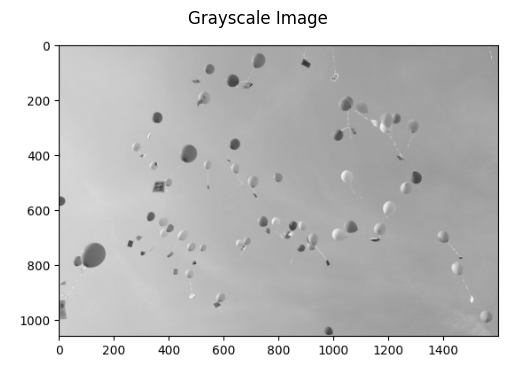

In [50]:
from google.colab import drive
from skimage import io, color
import matplotlib.pyplot as plt

# connect google drive
drive.mount('/content/drive')

# image path
path = '/content/drive/MyDrive/balloons.png'

# load the image
img = io.imread(path)

# remove alpha channel (RGBA -> RGB)
img = img[:, :, :3]

# convert to grayscale
gray = color.rgb2gray(img)

# show result
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.title('Grayscale Image')

plt.show()

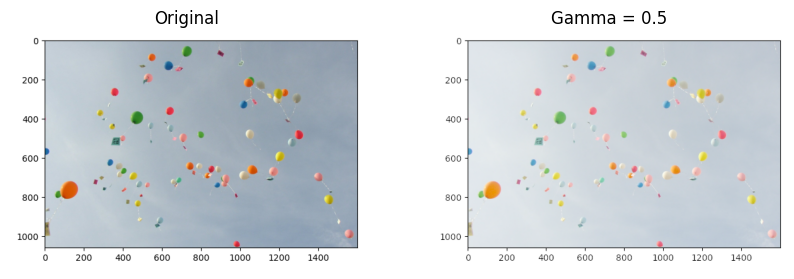

In [51]:
from skimage import io, exposure
import matplotlib.pyplot as plt

# load the image
img = io.imread('/content/drive/MyDrive/balloons.png')

# apply gamma correction
# gamma < 1 makes the image brighter
gamma_img = exposure.adjust_gamma(img, gamma=0.5)

# show original and corrected image
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gamma_img)
plt.title("Gamma = 0.5")
plt.axis('off')

plt.show()

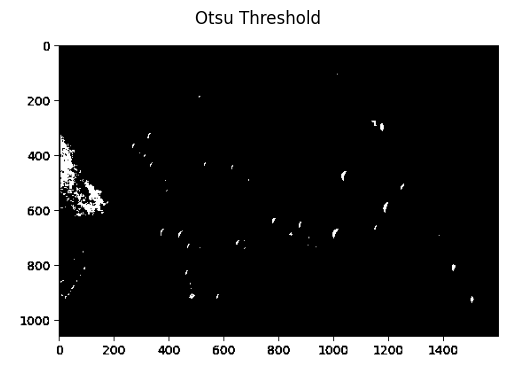

In [52]:
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

# find otsu threshold
thresh = threshold_otsu(gray)

# create binary image
binary = gray > thresh

# show result
plt.imshow(binary, cmap='gray')
plt.title('Otsu Threshold')
plt.axis('off')

plt.show()

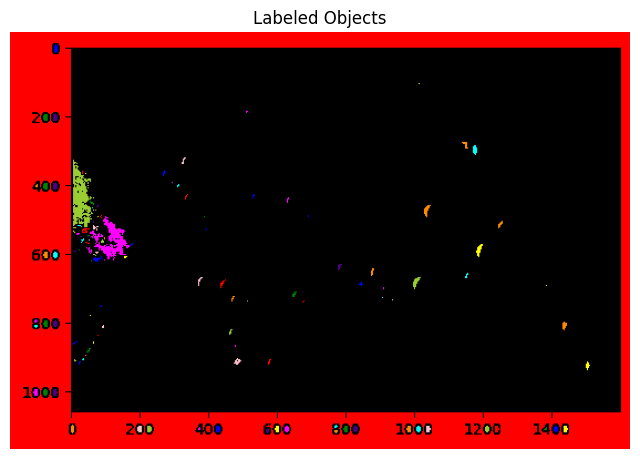

In [53]:
from skimage.measure import label
from skimage.color import label2rgb
import matplotlib.pyplot as plt

# label connected objects
labels = label(binary)

# give each object a different color
colored_labels = label2rgb(labels, bg_label=0)

# show labeled objects
plt.figure(figsize=(8,8))
plt.imshow(colored_labels)
plt.title('Labeled Objects')
plt.axis('off')

plt.show()

In [54]:
from skimage.measure import regionprops
import pandas as pd

# extract region properties
regions = regionprops(labels)

# store area and eccentricity
data = []

for region in regions:
    data.append({
        'Area': region.area,
        'Eccentricity': region.eccentricity
    })

# create table
df = pd.DataFrame(data)

# show results
print(df)

        Area  Eccentricity
0    45112.0      0.684255
1       20.0      0.918780
2        1.0      0.000000
3        3.0      0.816497
4       22.0      0.750757
..       ...           ...
122     20.0      0.798584
123      5.0      0.816497
124      6.0      0.816497
125     10.0      0.612372
126      7.0      0.377964

[127 rows x 2 columns]


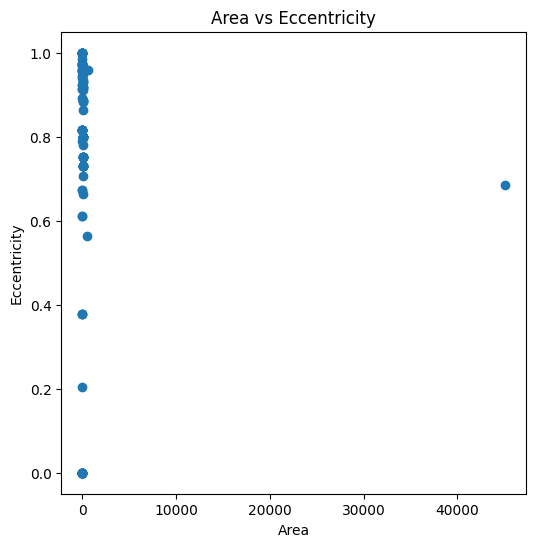

In [55]:
import matplotlib.pyplot as plt

# get area and eccentricity values
areas = [region.area for region in regions]
eccentricities = [region.eccentricity for region in regions]

# create scatter plot
plt.figure(figsize=(6,6))
plt.scatter(areas, eccentricities)

# axis labels
plt.xlabel('Area')
plt.ylabel('Eccentricity')

# plot title
plt.title('Area vs Eccentricity')

plt.show()

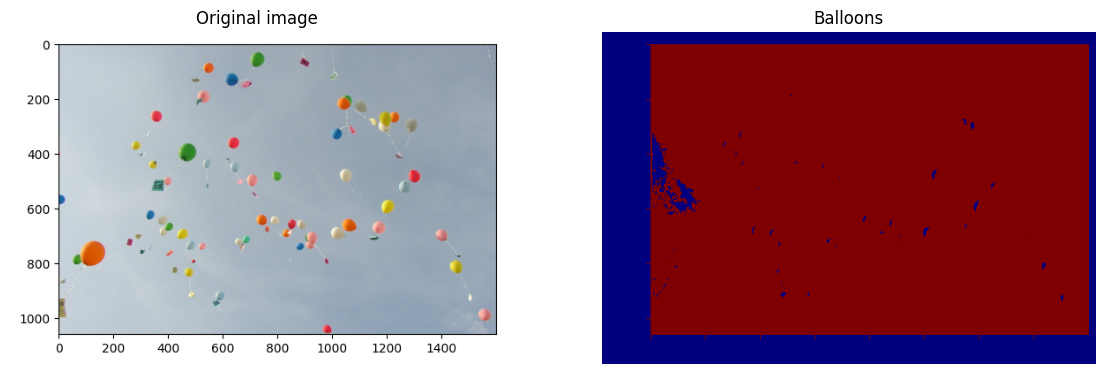

In [56]:
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
import numpy as np

# invert binary image
binary_inv = ~binary

# label connected regions
labels = label(binary_inv)

# extract properties
regions = regionprops(labels)

# create empty mask
balloons = np.zeros_like(binary_inv)

# keep objects that look like balloons
for region in regions:

    if region.area > 500 and region.eccentricity < 0.8:

        balloons[labels == region.label] = 1

# show original image and detected balloons
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Original image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(balloons, cmap='jet')
plt.title('Balloons')
plt.axis('off')

plt.show()